In [4]:
from pathlib import Path
from functools import partial
import sys
import json
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp
from scipy.optimize import minimize

sys.path.insert(0, str(Path.cwd()))
sys.path.insert(0, "/mnt/data")
from cartpole import CartPole

# -----------------------------
# Change this to "full" once quick mode works.
# -----------------------------
RUN_MODE = "full"
SEED = 492
rng = np.random.default_rng(SEED)

OUT = Path("sf3_week4_extensions")
FIG_DIR = OUT / "figures"
LOG_DIR = OUT / "logs"
DATA_DIR = OUT / "data"
for d in [OUT, FIG_DIR, LOG_DIR, DATA_DIR]:
    d.mkdir(parents=True, exist_ok=True)

if RUN_MODE == "quick":
    N_TRAIN, N_VAL, N_TEST = 180, 70, 70
    M_CENTRES = 35
    POLICY_RESTARTS = 0
    MAXITER_POLICY = 8
    H_NEAR = 25
    H_HARD = 35
    MC_SEEDS = 2
    NOISE_LEVELS = [0.0, 0.03, 0.06]
    MPC_TRUE_STEPS = 5
    MPC_HORIZON = 3
    MPC_MAXITER = 3
else:
    N_TRAIN, N_VAL, N_TEST = 1600, 450, 450
    M_CENTRES = 160
    POLICY_RESTARTS = 6
    MAXITER_POLICY = 150
    H_NEAR = 90
    H_HARD = 160
    MC_SEEDS = 30
    NOISE_LEVELS = [0.0, 0.005, 0.01, 0.03, 0.06, 0.10]
    MPC_TRUE_STEPS = 35
    MPC_HORIZON = 8
    MPC_MAXITER = 16

RUN_LIGHTWEIGHT_MPC = True

ACTION_LIMIT = 20.0
KERNEL_LENGTHSCALE = 1.25
KERNEL_LAMBDA = 1e-4
EFFORT_WEIGHT = 2e-3
DELTA_TIME = 0.1
MAX_FORCE = 20.0

# Loss scales: these are not the Week 2 kernel sigmas.
SIGMAS_NEAR = np.array([1.0, 2.0, 0.45, 3.0], dtype=float)
SIGMAS_HARD = np.array([2.0, 4.0, 1.0, 6.0], dtype=float)

near_init = np.array([0.0, 0.0, 0.20, 0.0], dtype=float)
hard_init = np.array([0.0, 0.0, -np.pi + 1.1, 0.0], dtype=float)
# This is intentionally not exactly pi or -pi.  It avoids the exact wrapped-angle boundary.

config = {
    "run_mode": RUN_MODE,
    "seed": SEED,
    "n_train": N_TRAIN,
    "n_val": N_VAL,
    "n_test": N_TEST,
    "m_centres": M_CENTRES,
    "action_limit": ACTION_LIMIT,
    "noise_levels": NOISE_LEVELS,
    "h_near": H_NEAR,
    "h_hard": H_HARD,
    "mc_seeds": MC_SEEDS,
    "run_lightweight_mpc": RUN_LIGHTWEIGHT_MPC,
}
with open(LOG_DIR / "week4_config.json", "w") as f:
    json.dump(config, f, indent=2)

jax.config.update("jax_enable_x64", True)
print(config)

{'run_mode': 'full', 'seed': 492, 'n_train': 1600, 'n_val': 450, 'n_test': 450, 'm_centres': 160, 'action_limit': 20.0, 'noise_levels': [0.0, 0.005, 0.01, 0.03, 0.06, 0.1], 'h_near': 90, 'h_hard': 160, 'mc_seeds': 30, 'run_lightweight_mpc': True}


In [6]:
# Constants copied from cartpole.py
SIM_STEPS = 50
POLE_LENGTH = 0.5
POLE_MASS = 0.5
CART_MASS = 0.5
MU_C = 0.001
MU_P = 0.001
GRAVITY = 9.8


def wrap_angle_np(theta):
    return (theta + np.pi) % (2 * np.pi) - np.pi


def wrap_angle(theta):
    return (theta + jnp.pi) % (2 * jnp.pi) - jnp.pi


def effective_force_np(action, max_force=MAX_FORCE):
    return max_force * np.tanh(np.asarray(action) / max_force)


@jax.jit
def cartpole_step_jax(state, action, max_force=MAX_FORCE):
    """One performAction-equivalent step in JAX."""
    x, x_dot, theta, theta_dot = state
    force = max_force * jnp.tanh(action / max_force)
    dt = DELTA_TIME / SIM_STEPS

    def euler_substep(carry, _):
        x, x_dot, theta, theta_dot = carry
        s = jnp.sin(theta)
        c = jnp.cos(theta)
        m = 4.0 * (CART_MASS + POLE_MASS) - 3.0 * POLE_MASS * (c ** 2)

        cart_accel = (
            2.0 * (POLE_LENGTH * POLE_MASS * (theta_dot ** 2) * s + 2.0 * (force - MU_C * x_dot))
            - 3.0 * POLE_MASS * GRAVITY * c * s
            + 6.0 * MU_P * theta_dot * c / POLE_LENGTH
        ) / m

        pole_accel = (
            -3.0 * c * (2.0 / POLE_LENGTH) * (
                POLE_LENGTH / 2.0 * POLE_MASS * (theta_dot ** 2) * s + force - MU_C * x_dot
            )
            + 6.0 * (CART_MASS + POLE_MASS) / (POLE_MASS * POLE_LENGTH) * (
                POLE_MASS * GRAVITY * s - 2.0 / POLE_LENGTH * MU_P * theta_dot
            )
        ) / m

        x_dot = x_dot + dt * cart_accel
        theta_dot = theta_dot + dt * pole_accel
        theta = theta + dt * theta_dot
        x = x + dt * x_dot
        return jnp.array([x, x_dot, theta, theta_dot]), None

    next_state, _ = jax.lax.scan(euler_substep, state, None, length=SIM_STEPS)
    return next_state


def linear_features(state):
    x, x_dot, theta, theta_dot = state
    return jnp.array([x, x_dot, wrap_angle(theta), theta_dot])


def nonlinear_features(state):
    x, x_dot, theta, theta_dot = state
    th = wrap_angle(theta)
    # All features are zero at the target state except cos(theta)-1, which is also zero at theta=0.
    return jnp.array([
        x,
        x_dot,
        th,
        theta_dot,
        jnp.sin(theta),
        jnp.cos(theta) - 1.0,
        th * theta_dot,
        x * x_dot,
        x * th,
        theta_dot * jnp.sin(theta),
    ])


def bounded_action(raw_action, action_limit=ACTION_LIMIT):
    return action_limit * jnp.tanh(raw_action / action_limit)


def policy_action_linear(p, state, action_limit=ACTION_LIMIT):
    return bounded_action(jnp.dot(p, linear_features(state)), action_limit)


def policy_action_nonlinear(p, state, action_limit=ACTION_LIMIT):
    return bounded_action(jnp.dot(p, nonlinear_features(state)), action_limit)


def point_loss(state, sigmas):
    x, x_dot, theta, theta_dot = state
    err = jnp.array([x, x_dot, wrap_angle(theta), theta_dot])
    z2 = jnp.sum((err / sigmas) ** 2)
    return 1.0 - jnp.exp(-0.5 * z2)


def rollout_loss_linear(p, init_state, horizon, sigmas, effort_weight=EFFORT_WEIGHT, action_limit=ACTION_LIMIT):
    def body(state, _):
        action = policy_action_linear(p, state, action_limit)
        next_state = cartpole_step_jax(state, action)
        effort = jnp.tanh(action / MAX_FORCE) ** 2
        loss_t = point_loss(next_state, sigmas) + effort_weight * effort
        return next_state, loss_t
    _, losses = jax.lax.scan(body, init_state, None, length=horizon)
    return jnp.mean(losses)


def rollout_loss_nonlinear(p, init_state, horizon, sigmas, effort_weight=EFFORT_WEIGHT, action_limit=ACTION_LIMIT):
    def body(state, _):
        action = policy_action_nonlinear(p, state, action_limit)
        next_state = cartpole_step_jax(state, action)
        effort = jnp.tanh(action / MAX_FORCE) ** 2
        loss_t = point_loss(next_state, sigmas) + effort_weight * effort
        return next_state, loss_t
    _, losses = jax.lax.scan(body, init_state, None, length=horizon)
    return jnp.mean(losses)

loss_and_grad_linear = jax.jit(jax.value_and_grad(rollout_loss_linear), static_argnums=(2,))
loss_and_grad_nonlinear = jax.jit(jax.value_and_grad(rollout_loss_nonlinear), static_argnums=(2,))

print("linear feature dimension:", len(linear_features(jnp.asarray(near_init))))
print("nonlinear feature dimension:", len(nonlinear_features(jnp.asarray(near_init))))

linear feature dimension: 4
nonlinear feature dimension: 10


In [8]:
def make_objective(kind, init_state, horizon, sigmas):
    init_j = jnp.asarray(init_state, dtype=jnp.float64)
    sig_j = jnp.asarray(sigmas, dtype=jnp.float64)
    loss_grad = loss_and_grad_linear if kind == "linear" else loss_and_grad_nonlinear

    def objective(p_np):
        p_j = jnp.asarray(p_np, dtype=jnp.float64)
        val, grad = loss_grad(p_j, init_j, int(horizon), sig_j, EFFORT_WEIGHT, ACTION_LIMIT)
        return float(val), np.asarray(grad, dtype=float)

    return objective


def optimise_policy(kind, init_state, horizon, sigmas, seed=SEED, maxiter=MAXITER_POLICY, restarts=POLICY_RESTARTS):
    local_rng = np.random.default_rng(seed)
    n_params = 4 if kind == "linear" else 10

    base = []
    if kind == "linear":
        base = [
            np.zeros(4),
            np.array([0.0, 0.0, 10.0, 2.0]),
            np.array([-1.0, -2.0, 18.0, 5.0]),
        ]
        random_scale = 8.0
    else:
        # Start from embedded linear controllers and allow nonlinear coefficients to grow from zero.
        for lin in [np.zeros(4), np.array([0, 0, 12, 3])]:
            p = np.zeros(10)
            p[:4] = lin
            base.append(p)
        random_scale = 4.0

    guesses = list(base)
    for _ in range(restarts):
        guesses.append(local_rng.normal(0.0, random_scale, size=n_params))

    objective = make_objective(kind, init_state, horizon, sigmas)
    rows = []
    best = None
    bound = 45.0 if kind == "linear" else 35.0

    for i, guess in enumerate(guesses):
        result = minimize(
            fun=lambda p: objective(p),
            x0=guess,
            jac=True,
            method="L-BFGS-B",
            bounds=[(-bound, bound)] * n_params,
            options={"maxiter": maxiter, "ftol": 1e-9},
        )
        rows.append({
            "restart": i,
            "kind": kind,
            "loss": float(result.fun),
            "success": bool(result.success),
            "n_iter": int(result.nit),
            "p": result.x.copy(),
            "message": str(result.message),
        })
        if best is None or result.fun < best.fun:
            best = result

    df = pd.DataFrame(rows).sort_values("loss").reset_index(drop=True)
    return best, df


def rollout_policy_np(kind, p, init_state, horizon, sigmas, obs_noise=0.0, process_noise=0.0, action_noise=0.0, seed=0):
    """Rollout a policy on true dynamics, optionally adding noise during evaluation."""
    local_rng = np.random.default_rng(seed)
    state = np.asarray(init_state, dtype=float).copy()
    rows = []
    state_scale = np.array([5.0, 10.0, np.pi, 15.0])
    sig_j = jnp.asarray(sigmas, dtype=jnp.float64)

    for t in range(horizon):
        observed = state.copy()
        if obs_noise > 0:
            observed += local_rng.normal(0.0, obs_noise * state_scale)
        observed[2] = wrap_angle_np(observed[2])

        if kind == "linear":
            action = float(policy_action_linear(jnp.asarray(p), jnp.asarray(observed), ACTION_LIMIT))
        else:
            action = float(policy_action_nonlinear(jnp.asarray(p), jnp.asarray(observed), ACTION_LIMIT))
        if action_noise > 0:
            action += float(local_rng.normal(0.0, action_noise * ACTION_LIMIT))
        action = float(np.clip(action, -ACTION_LIMIT, ACTION_LIMIT))

        next_state = np.asarray(cartpole_step_jax(jnp.asarray(state, dtype=jnp.float64), action)).copy()
        if process_noise > 0:
            next_state += local_rng.normal(0.0, process_noise * state_scale)
        next_state[2] = wrap_angle_np(next_state[2])

        loss_t = float(point_loss(jnp.asarray(next_state), sig_j))
        rows.append({
            "time": (t + 1) * DELTA_TIME,
            "x": next_state[0],
            "x_dot": next_state[1],
            "theta_wrapped": next_state[2],
            "theta_dot": next_state[3],
            "action": action,
            "effective_force": float(effective_force_np(action)),
            "point_loss": loss_t,
        })
        state = next_state
    return pd.DataFrame(rows)


def plot_policy_comparison(kind_to_result, init_state, horizon, sigmas, title, filename):
    fig, axes = plt.subplots(3, 1, figsize=(7.2, 7.0), sharex=True)
    for label, (kind, p) in kind_to_result.items():
        df = rollout_policy_np(kind, p, init_state, horizon, sigmas)
        axes[0].plot(df["time"], df["theta_wrapped"], label=label)
        axes[1].plot(df["time"], df["x"], label=label)
        axes[2].plot(df["time"], df["action"], label=label)
    axes[0].axhline(0, linestyle="--", linewidth=1)
    axes[1].axhline(0, linestyle="--", linewidth=1)
    axes[2].axhline(0, linestyle="--", linewidth=1)
    axes[0].set_ylabel("wrapped theta")
    axes[1].set_ylabel("cart position x")
    axes[2].set_ylabel("command action u")
    axes[2].set_xlabel("time / s")
    axes[0].set_title(title)
    for ax in axes:
        ax.grid(True, alpha=0.3)
        ax.legend()
    fig.tight_layout()
    fig.savefig(FIG_DIR / filename, dpi=180)
    plt.show()


def evaluate_policy_summary(kind, p, init_state, horizon, sigmas, label):
    df = rollout_policy_np(kind, p, init_state, horizon, sigmas)
    return {
        "label": label,
        "kind": kind,
        "mean_loss": float(df["point_loss"].mean()),
        "final_abs_theta": float(abs(df["theta_wrapped"].iloc[-1])),
        "final_abs_x": float(abs(df["x"].iloc[-1])),
        "max_abs_action": float(abs(df["action"]).max()),
        "final_abs_theta_dot": float(abs(df["theta_dot"].iloc[-1])),
    }

In [10]:
start = time.time()

print("Optimising linear and nonlinear policies from near-upright initial condition...")
best_lin_near, runs_lin_near = optimise_policy("linear", near_init, H_NEAR, SIGMAS_NEAR, seed=SEED + 1)
best_nonlin_near, runs_nonlin_near = optimise_policy("nonlinear", near_init, H_NEAR, SIGMAS_NEAR, seed=SEED + 2)

print("Optimising linear and nonlinear policies from harder initial condition...")
best_lin_hard, runs_lin_hard = optimise_policy("linear", hard_init, H_HARD, SIGMAS_HARD, seed=SEED + 3)
best_nonlin_hard, runs_nonlin_hard = optimise_policy("nonlinear", hard_init, H_HARD, SIGMAS_HARD, seed=SEED + 4)

policy_summary = pd.DataFrame([
    evaluate_policy_summary("linear", best_lin_near.x, near_init, H_NEAR, SIGMAS_NEAR, "linear_near"),
    evaluate_policy_summary("nonlinear", best_nonlin_near.x, near_init, H_NEAR, SIGMAS_NEAR, "nonlinear_near"),
    evaluate_policy_summary("linear", best_lin_hard.x, hard_init, H_HARD, SIGMAS_HARD, "linear_hard"),
    evaluate_policy_summary("nonlinear", best_nonlin_hard.x, hard_init, H_HARD, SIGMAS_HARD, "nonlinear_hard"),
])

# Add optimiser losses.
opt_losses = {
    "linear_near": best_lin_near.fun,
    "nonlinear_near": best_nonlin_near.fun,
    "linear_hard": best_lin_hard.fun,
    "nonlinear_hard": best_nonlin_hard.fun,
}
policy_summary["optimisation_loss"] = policy_summary["label"].map(opt_losses)

policy_summary.to_csv(LOG_DIR / "week4_nonlinear_policy_summary.csv", index=False)
runs_lin_near.to_csv(LOG_DIR / "week4_restarts_linear_near.csv", index=False)
runs_nonlin_near.to_csv(LOG_DIR / "week4_restarts_nonlinear_near.csv", index=False)
runs_lin_hard.to_csv(LOG_DIR / "week4_restarts_linear_hard.csv", index=False)
runs_nonlin_hard.to_csv(LOG_DIR / "week4_restarts_nonlinear_hard.csv", index=False)

display(policy_summary)
print(f"Policy optimisation time: {time.time()-start:.1f} s")

Optimising linear and nonlinear policies from near-upright initial condition...
Optimising linear and nonlinear policies from harder initial condition...


,label,kind,mean_loss,final_abs_theta,final_abs_x,max_abs_action,final_abs_theta_dot,optimisation_loss
0,linear_near,linear,0.005534,5.948759e-08,7.853239e-08,6.184643,9.586571e-08,0.005537
1,nonlinear_near,nonlinear,0.005540,8.323381e-07,5.986922e-06,6.186183,9.874200e-07,0.005543
2,linear_hard,linear,0.825939,1.317122e+00,1.539245e+02,4.190862,1.206037e+01,0.800457
3,nonlinear_hard,nonlinear,0.072222,5.782051e-03,1.033929e-01,19.580364,4.588229e-03,0.072243


Policy optimisation time: 5.3 s


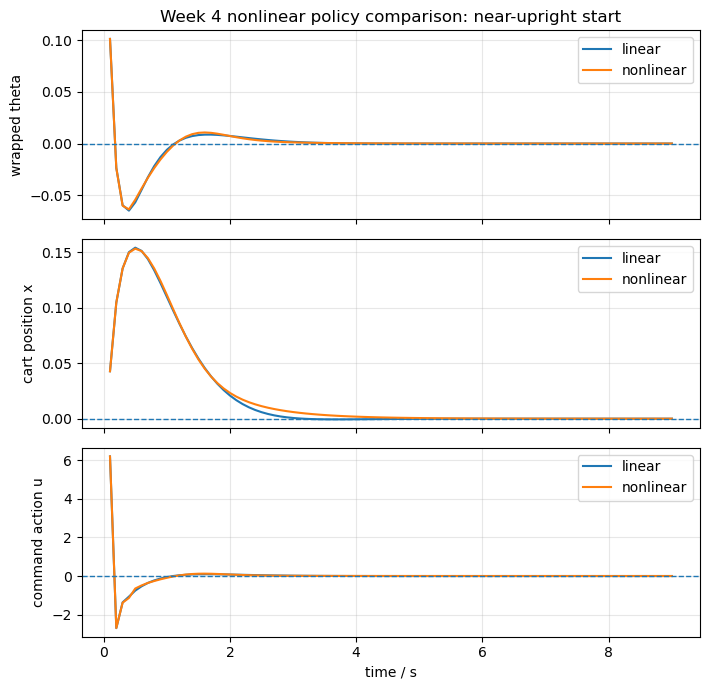

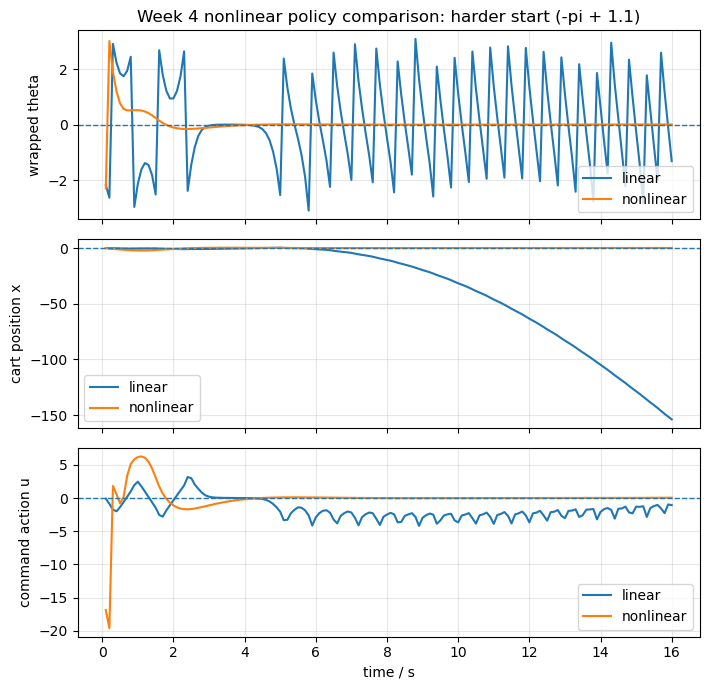

In [11]:
plot_policy_comparison(
    {
        "linear": ("linear", best_lin_near.x),
        "nonlinear": ("nonlinear", best_nonlin_near.x),
    },
    near_init,
    H_NEAR,
    SIGMAS_NEAR,
    "Week 4 nonlinear policy comparison: near-upright start",
    "week4_nonlinear_policy_compare_near.png",
)

plot_policy_comparison(
    {
        "linear": ("linear", best_lin_hard.x),
        "nonlinear": ("nonlinear", best_nonlin_hard.x),
    },
    hard_init,
    H_HARD,
    SIGMAS_HARD,
    "Week 4 nonlinear policy comparison: harder start (-pi + 1.1)",
    "week4_nonlinear_policy_compare_hard.png",
)

In [13]:
STATE_RANGES = np.array([
    [-5.0, 5.0],
    [-10.0, 10.0],
    [-np.pi, np.pi],
    [-15.0, 15.0],
], dtype=float)
STATE_SCALE = np.array([5.0, 10.0, np.pi, 15.0], dtype=float)


def one_step_delta_np(state, action):
    system = CartPole(visual=False)
    system.setState(state)
    x0 = system.getState().copy()
    system.performAction(float(action))
    x1 = system.getState().copy()
    return x1 - x0


def sample_states(n, rng):
    low = STATE_RANGES[:, 0]
    high = STATE_RANGES[:, 1]
    return rng.uniform(low, high, size=(n, 4))


def sample_dataset(n, action_limit, rng):
    states = sample_states(n, rng)
    actions = rng.uniform(-action_limit, action_limit, size=n)
    X = np.column_stack([states, actions])
    Y = np.zeros((n, 4))
    for i in range(n):
        Y[i] = one_step_delta_np(states[i], actions[i])
    return X, Y


def sincos_action_features_np(X5):
    x, x_dot, theta, theta_dot, u = X5.T
    return np.column_stack([x, x_dot, np.sin(theta), np.cos(theta), theta_dot, u])


class Standardiser:
    def fit(self, X):
        self.mean = np.mean(X, axis=0)
        self.std = np.std(X, axis=0)
        self.std[self.std < 1e-12] = 1.0
        return self
    def transform(self, X):
        return (X - self.mean) / self.std
    def fit_transform(self, X):
        return self.fit(X).transform(X)


def add_intercept(A):
    return np.column_stack([A, np.ones(A.shape[0])])


def rbf_kernel_np(A, B, lengthscale=1.0):
    diff = A[:, None, :] - B[None, :, :]
    return np.exp(-0.5 * np.sum((diff / lengthscale) ** 2, axis=2))


class AffineDeltaModel:
    @classmethod
    def fit(cls, X5, Y):
        obj = cls()
        Phi = sincos_action_features_np(X5)
        obj.std = Standardiser().fit(Phi)
        A = add_intercept(obj.std.transform(Phi))
        reg = 1e-8
        obj.coef = np.linalg.solve(A.T @ A + reg * np.eye(A.shape[1]), A.T @ Y)
        return obj
    def predict_delta(self, X5):
        Phi = sincos_action_features_np(X5)
        A = add_intercept(self.std.transform(Phi))
        return A @ self.coef


class SparseKernelDeltaModel:
    @classmethod
    def fit(cls, X5, Y, m_centres, rng, lengthscale=KERNEL_LENGTHSCALE, lam=KERNEL_LAMBDA):
        obj = cls()
        Phi = sincos_action_features_np(X5)
        obj.std = Standardiser().fit(Phi)
        Phi_s = obj.std.transform(Phi)
        m = min(m_centres, len(X5))
        idx = rng.choice(len(X5), size=m, replace=False)
        obj.centres = Phi_s[idx]
        obj.lengthscale = lengthscale
        obj.lam = lam
        K_NM = rbf_kernel_np(Phi_s, obj.centres, lengthscale)
        K_MN = K_NM.T
        K_MM = rbf_kernel_np(obj.centres, obj.centres, lengthscale)
        A = K_MN @ K_NM + lam * K_MM + 1e-8 * np.eye(m)
        B = K_MN @ Y
        obj.alpha = np.linalg.solve(A, B)
        return obj
    def predict_delta(self, X5):
        Phi = sincos_action_features_np(X5)
        Phi_s = self.std.transform(Phi)
        K = rbf_kernel_np(Phi_s, self.centres, self.lengthscale)
        return K @ self.alpha


def evaluate_delta_model(model, X, Y, label):
    pred = model.predict_delta(X)
    err = pred - Y
    raw = np.mean(err ** 2, axis=0)
    scale = np.std(Y, axis=0)
    scale[scale < 1e-12] = 1.0
    std = np.mean((err / scale) ** 2, axis=0)
    return {
        "model": label,
        "raw_mse_mean": float(np.mean(raw)),
        "std_mse_mean": float(np.mean(std)),
        "std_mse_delta_x": float(std[0]),
        "std_mse_delta_x_dot": float(std[1]),
        "std_mse_delta_theta": float(std[2]),
        "std_mse_delta_theta_dot": float(std[3]),
    }


def add_observation_noise(X, Y, noise_level, rng, target_scale=None):
    Xn = X.copy()
    Yn = Y.copy()
    if noise_level <= 0:
        return Xn, Yn
    Xn[:, :4] += rng.normal(0.0, noise_level * STATE_SCALE, size=Xn[:, :4].shape)
    Xn[:, 2] = wrap_angle_np(Xn[:, 2])
    if target_scale is None:
        target_scale = np.std(Y, axis=0)
    target_scale = np.where(target_scale < 1e-12, 1.0, target_scale)
    Yn += rng.normal(0.0, noise_level * target_scale, size=Yn.shape)
    return Xn, Yn

Generating clean transition datasets for noisy-observation extension...


,model,raw_mse_mean,std_mse_mean,std_mse_delta_x,std_mse_delta_x_dot,std_mse_delta_theta,std_mse_delta_theta_dot,noise_level,split
0,affine,2.460895,0.239484,0.003204,0.221595,0.032020,0.701118,0.000,validation_clean
1,sparse_kernel,0.296156,0.059317,0.037135,0.087801,0.040766,0.071566,0.000,validation_clean
2,affine,2.854036,0.236270,0.003995,0.230381,0.035521,0.675182,0.000,test_clean
3,sparse_kernel,0.358576,0.055420,0.028884,0.080248,0.037830,0.074717,0.000,test_clean
4,affine,2.461078,0.239500,0.003206,0.221592,0.032029,0.701173,0.005,validation_clean
5,sparse_kernel,0.257801,0.053838,0.035500,0.081991,0.036586,0.061275,0.005,validation_clean
6,affine,2.854941,0.236334,0.003991,0.230401,0.035543,0.675403,0.005,test_clean
7,sparse_kernel,0.298393,0.050848,0.029066,0.079405,0.034954,0.059966,0.005,test_clean
8,affine,2.460640,0.239448,0.003222,0.221474,0.032036,0.701059,0.010,validation_clean
9,sparse_kernel,0.294838,0.052412,0.034414,0.070508,0.030125,0.074602,0.010,validation_clean


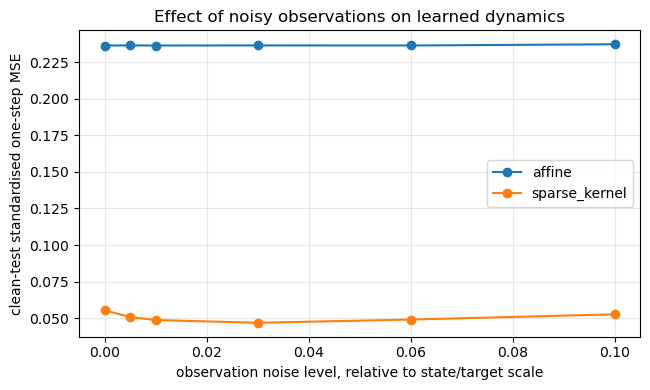

In [14]:
print("Generating clean transition datasets for noisy-observation extension...")
data_rng = np.random.default_rng(SEED + 200)
X_train_clean, Y_train_clean = sample_dataset(N_TRAIN, ACTION_LIMIT, data_rng)
X_val_clean, Y_val_clean = sample_dataset(N_VAL, ACTION_LIMIT, data_rng)
X_test_clean, Y_test_clean = sample_dataset(N_TEST, ACTION_LIMIT, data_rng)
target_scale = np.std(Y_train_clean, axis=0)

noise_rows = []
models_by_noise = {}

for noise_level in NOISE_LEVELS:
    local_rng = np.random.default_rng(SEED + int(noise_level * 10000) + 300)
    Xn, Yn = add_observation_noise(X_train_clean, Y_train_clean, noise_level, local_rng, target_scale=target_scale)
    affine = AffineDeltaModel.fit(Xn, Yn)
    kernel = SparseKernelDeltaModel.fit(Xn, Yn, M_CENTRES, local_rng)
    models_by_noise[noise_level] = {"affine": affine, "kernel": kernel}

    for split, X, Y in [("validation_clean", X_val_clean, Y_val_clean), ("test_clean", X_test_clean, Y_test_clean)]:
        for label, model in [("affine", affine), ("sparse_kernel", kernel)]:
            row = evaluate_delta_model(model, X, Y, label)
            row.update({"noise_level": noise_level, "split": split})
            noise_rows.append(row)

noise_df = pd.DataFrame(noise_rows)
noise_df.to_csv(LOG_DIR / "week4_observation_noise_model_mse.csv", index=False)
display(noise_df)

plot_df = noise_df[noise_df["split"] == "test_clean"]
fig, ax = plt.subplots(figsize=(6.6, 4.0))
for model in ["affine", "sparse_kernel"]:
    sub = plot_df[plot_df["model"] == model]
    ax.plot(sub["noise_level"], sub["std_mse_mean"], marker="o", label=model)
ax.set_xlabel("observation noise level, relative to state/target scale")
ax.set_ylabel("clean-test standardised one-step MSE")
ax.set_title("Effect of noisy observations on learned dynamics")
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "week4_observation_noise_model_mse.png", dpi=180)
plt.show()

,policy,noise_type,noise_level,mean_loss,std_loss,success_rate,mean_final_abs_theta
0,linear_near,action,0.000,0.005534,0.000000,1.000000,5.948759e-08
1,linear_near,action,0.005,0.006006,0.000071,1.000000,2.778268e-03
2,linear_near,action,0.010,0.007412,0.000281,1.000000,5.565118e-03
3,linear_near,action,0.030,0.021613,0.002219,1.000000,1.697850e-02
4,linear_near,action,0.060,0.062616,0.006581,1.000000,3.598474e-02
5,linear_near,action,0.100,0.140803,0.013944,1.000000,6.749519e-02
6,linear_near,observation,0.000,0.005534,0.000000,1.000000,5.948759e-08
7,linear_near,observation,0.005,0.026348,0.002898,1.000000,2.266545e-02
8,linear_near,observation,0.010,0.075715,0.008422,1.000000,4.595996e-02
9,linear_near,observation,0.030,0.657222,0.233088,0.266667,1.127889e+00


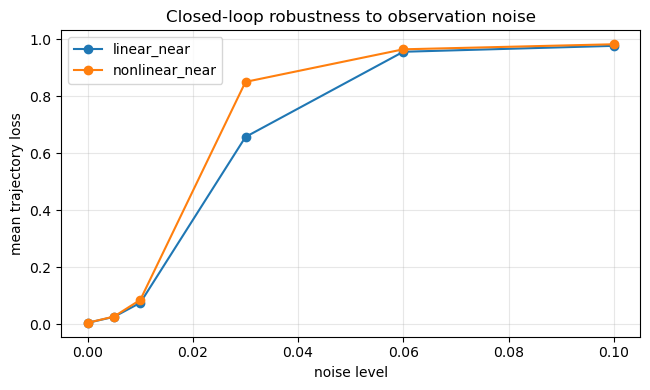

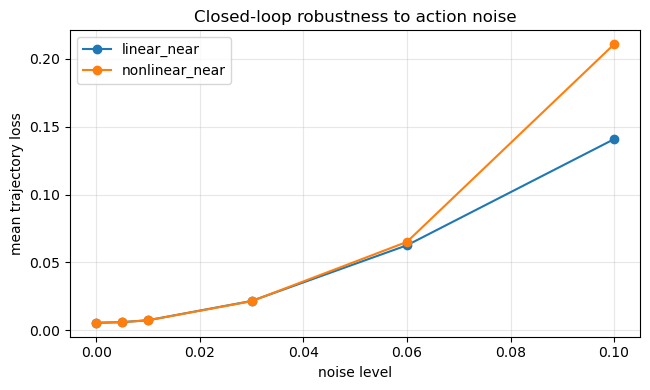

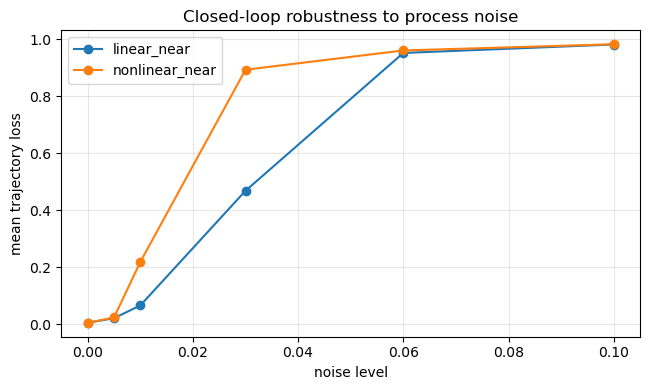

In [16]:
def noisy_rollout_experiment(kind, p, init_state, horizon, sigmas, label, noise_levels, mc_seeds=MC_SEEDS):
    rows = []
    for noise_type in ["observation", "action", "process"]:
        for level in noise_levels:
            for s in range(mc_seeds):
                kwargs = {"obs_noise": 0.0, "action_noise": 0.0, "process_noise": 0.0}
                if noise_type == "observation":
                    kwargs["obs_noise"] = level
                elif noise_type == "action":
                    kwargs["action_noise"] = level
                else:
                    kwargs["process_noise"] = level
                df = rollout_policy_np(kind, p, init_state, horizon, sigmas, seed=SEED + 5000 + s, **kwargs)
                rows.append({
                    "policy": label,
                    "noise_type": noise_type,
                    "noise_level": level,
                    "seed": s,
                    "mean_loss": float(df["point_loss"].mean()),
                    "final_abs_theta": float(abs(df["theta_wrapped"].iloc[-1])),
                    "final_abs_x": float(abs(df["x"].iloc[-1])),
                    "max_abs_action": float(abs(df["action"]).max()),
                    "success_final_theta_lt_0p25": bool(abs(df["theta_wrapped"].iloc[-1]) < 0.25),
                })
    return pd.DataFrame(rows)

robust_df = pd.concat([
    noisy_rollout_experiment("linear", best_lin_near.x, near_init, H_NEAR, SIGMAS_NEAR, "linear_near", NOISE_LEVELS),
    noisy_rollout_experiment("nonlinear", best_nonlin_near.x, near_init, H_NEAR, SIGMAS_NEAR, "nonlinear_near", NOISE_LEVELS),
], ignore_index=True)
robust_df.to_csv(LOG_DIR / "week4_noisy_policy_rollout_raw.csv", index=False)

robust_summary = robust_df.groupby(["policy", "noise_type", "noise_level"], as_index=False).agg(
    mean_loss=("mean_loss", "mean"),
    std_loss=("mean_loss", "std"),
    success_rate=("success_final_theta_lt_0p25", "mean"),
    mean_final_abs_theta=("final_abs_theta", "mean"),
)
robust_summary.to_csv(LOG_DIR / "week4_noisy_policy_rollout_summary.csv", index=False)
display(robust_summary)

for noise_type in ["observation", "action", "process"]:
    fig, ax = plt.subplots(figsize=(6.6, 4.0))
    sub_type = robust_summary[robust_summary["noise_type"] == noise_type]
    for policy in sorted(sub_type["policy"].unique()):
        sub = sub_type[sub_type["policy"] == policy]
        ax.plot(sub["noise_level"], sub["mean_loss"], marker="o", label=policy)
    ax.set_xlabel("noise level")
    ax.set_ylabel("mean trajectory loss")
    ax.set_title(f"Closed-loop robustness to {noise_type} noise")
    ax.grid(True, alpha=0.3)
    ax.legend()
    fig.tight_layout()
    fig.savefig(FIG_DIR / f"week4_policy_robustness_{noise_type}.png", dpi=180)
    plt.show()

Running lightweight learned-model MPC probe...


,time,x,x_dot,theta_wrapped,theta_dot,action,effective_force,point_loss,mpc_objective,mpc_success
30,3.1,1.148402,-2.498749,-0.824759,6.901386,-15.432518,-12.957478,0.996866,0.377948,False
31,3.2,0.859272,-3.258875,-0.123415,7.508480,-4.172498,-4.112999,0.992299,0.291591,False
32,3.3,0.606692,-1.854166,0.422157,3.894630,9.923211,9.181846,0.849906,0.197595,False
33,3.4,0.479840,-0.745715,0.736207,2.734040,9.906233,9.168441,0.856035,0.296648,False
34,3.5,0.341156,-1.854147,1.249111,7.095199,-11.966273,-10.716970,0.999205,0.644591,False


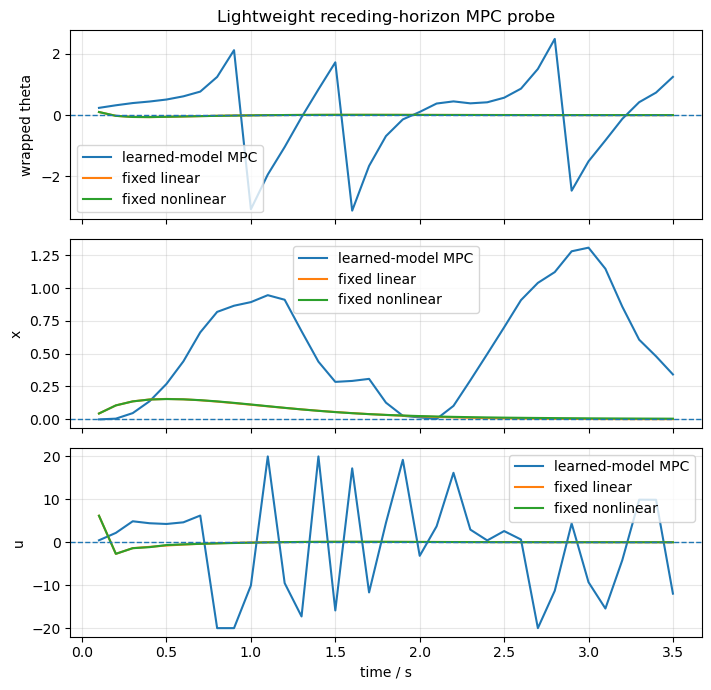

,method,mean_loss,final_abs_theta,max_abs_action
0,learned_model_mpc,0.806002,1.249111,20.000000
1,fixed_linear,0.014230,0.000546,6.184643
2,fixed_nonlinear,0.014246,0.000527,6.186183


In [18]:
# Convert the clean sparse-kernel dynamics model from Section 4 into JAX arrays.
clean_model = models_by_noise[0.0]["kernel"]
model_params = {
    "mean": jnp.asarray(clean_model.std.mean, dtype=jnp.float64),
    "std": jnp.asarray(clean_model.std.std, dtype=jnp.float64),
    "centres": jnp.asarray(clean_model.centres, dtype=jnp.float64),
    "alpha": jnp.asarray(clean_model.alpha, dtype=jnp.float64),
    "lengthscale": float(clean_model.lengthscale),
}


def model_features_jax(state, action):
    x, x_dot, theta, theta_dot = state
    return jnp.array([x, x_dot, jnp.sin(theta), jnp.cos(theta), theta_dot, action])


def model_delta_jax(state, action, params):
    phi = model_features_jax(state, action)
    phi_s = (phi - params["mean"]) / params["std"]
    diff = (phi_s[None, :] - params["centres"]) / params["lengthscale"]
    k = jnp.exp(-0.5 * jnp.sum(diff ** 2, axis=1))
    return k @ params["alpha"]


def model_step_jax(state, action, params):
    next_state = state + model_delta_jax(state, action, params)
    return next_state.at[2].set(wrap_angle(next_state[2]))


def action_sequence_model_loss(actions, init_state, horizon, sigmas, params):
    def body(state, a):
        a = jnp.clip(a, -ACTION_LIMIT, ACTION_LIMIT)
        next_state = model_step_jax(state, a, params)
        loss_t = point_loss(next_state, sigmas) + EFFORT_WEIGHT * (jnp.tanh(a / MAX_FORCE) ** 2)
        return next_state, loss_t
    _, losses = jax.lax.scan(body, init_state, actions, length=horizon)
    return jnp.mean(losses)

seq_loss_grad = jax.jit(jax.value_and_grad(action_sequence_model_loss), static_argnums=(2,))


def optimise_action_sequence(init_state, horizon, sigmas, params, guess=None, maxiter=MPC_MAXITER):
    if guess is None:
        guess = np.zeros(horizon)
    init_j = jnp.asarray(init_state, dtype=jnp.float64)
    sig_j = jnp.asarray(sigmas, dtype=jnp.float64)

    def obj(a_np):
        a_j = jnp.asarray(a_np, dtype=jnp.float64)
        val, grad = seq_loss_grad(a_j, init_j, int(horizon), sig_j, params)
        return float(val), np.asarray(grad, dtype=float)

    result = minimize(
        fun=lambda a: obj(a),
        x0=guess,
        jac=True,
        method="L-BFGS-B",
        bounds=[(-ACTION_LIMIT, ACTION_LIMIT)] * horizon,
        options={"maxiter": maxiter, "ftol": 1e-7},
    )
    return result


def run_lightweight_mpc(init_state, true_steps, mpc_horizon, sigmas, params):
    state = np.asarray(init_state, dtype=float).copy()
    guess = np.zeros(mpc_horizon)
    rows = []
    for t in range(true_steps):
        res = optimise_action_sequence(state, mpc_horizon, sigmas, params, guess=guess)
        action = float(res.x[0])
        next_state = np.asarray(cartpole_step_jax(jnp.asarray(state, dtype=jnp.float64), action)).copy()
        next_state[2] = wrap_angle_np(next_state[2])
        loss_t = float(point_loss(jnp.asarray(next_state), jnp.asarray(sigmas)))
        rows.append({
            "time": (t + 1) * DELTA_TIME,
            "x": next_state[0],
            "x_dot": next_state[1],
            "theta_wrapped": next_state[2],
            "theta_dot": next_state[3],
            "action": action,
            "effective_force": float(effective_force_np(action)),
            "point_loss": loss_t,
            "mpc_objective": float(res.fun),
            "mpc_success": bool(res.success),
        })
        state = next_state
        guess = np.r_[res.x[1:], 0.0]
    return pd.DataFrame(rows)

if RUN_LIGHTWEIGHT_MPC:
    print("Running lightweight learned-model MPC probe...")
    mpc_df = run_lightweight_mpc(near_init, MPC_TRUE_STEPS, MPC_HORIZON, SIGMAS_NEAR, model_params)
    mpc_df.to_csv(LOG_DIR / "week4_lightweight_mpc_probe.csv", index=False)
    display(mpc_df.tail())

    # Compare with the optimised linear and nonlinear fixed policies over the same time window.
    fixed_lin_df = rollout_policy_np("linear", best_lin_near.x, near_init, MPC_TRUE_STEPS, SIGMAS_NEAR)
    fixed_nonlin_df = rollout_policy_np("nonlinear", best_nonlin_near.x, near_init, MPC_TRUE_STEPS, SIGMAS_NEAR)

    fig, axes = plt.subplots(3, 1, figsize=(7.2, 7.0), sharex=True)
    for label, df in [("learned-model MPC", mpc_df), ("fixed linear", fixed_lin_df), ("fixed nonlinear", fixed_nonlin_df)]:
        axes[0].plot(df["time"], df["theta_wrapped"], label=label)
        axes[1].plot(df["time"], df["x"], label=label)
        axes[2].plot(df["time"], df["action"], label=label)
    axes[0].axhline(0, linestyle="--", linewidth=1)
    axes[1].axhline(0, linestyle="--", linewidth=1)
    axes[2].axhline(0, linestyle="--", linewidth=1)
    axes[0].set_ylabel("wrapped theta")
    axes[1].set_ylabel("x")
    axes[2].set_ylabel("u")
    axes[2].set_xlabel("time / s")
    axes[0].set_title("Lightweight receding-horizon MPC probe")
    for ax in axes:
        ax.grid(True, alpha=0.3)
        ax.legend()
    fig.tight_layout()
    fig.savefig(FIG_DIR / "week4_lightweight_mpc_probe.png", dpi=180)
    plt.show()

    mpc_summary = pd.DataFrame([
        {"method": "learned_model_mpc", "mean_loss": mpc_df["point_loss"].mean(), "final_abs_theta": abs(mpc_df["theta_wrapped"].iloc[-1]), "max_abs_action": abs(mpc_df["action"]).max()},
        {"method": "fixed_linear", "mean_loss": fixed_lin_df["point_loss"].mean(), "final_abs_theta": abs(fixed_lin_df["theta_wrapped"].iloc[-1]), "max_abs_action": abs(fixed_lin_df["action"]).max()},
        {"method": "fixed_nonlinear", "mean_loss": fixed_nonlin_df["point_loss"].mean(), "final_abs_theta": abs(fixed_nonlin_df["theta_wrapped"].iloc[-1]), "max_abs_action": abs(fixed_nonlin_df["action"]).max()},
    ])
    mpc_summary.to_csv(LOG_DIR / "week4_lightweight_mpc_summary.csv", index=False)
    display(mpc_summary)
else:
    print("MPC probe skipped. Set RUN_LIGHTWEIGHT_MPC = True to run it.")